# Week 14 V2: CodeGnosis - Fixed Methodology

## Issues Fixed from V1

1. **More data**: 100+ tasks instead of 40
2. **Proper split**: Train/Val/Test with NO data leakage
3. **Harder tasks**: Tasks that actually cause errors
4. **Fair comparison**: CCE threshold tuned on VALIDATION set only
5. **Cross-validation**: K-fold to get reliable estimates

## Key Question

Can hidden states predict errors BETTER than raw output entropy (CCE)?

In [1]:
!pip install -q torch transformers accelerate bitsandbytes scipy numpy pandas matplotlib scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 17.7 MB/s eta 0:00:00


In [2]:
import os
import ast
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import random
from typing import List, Dict, Tuple, Optional
from dataclasses import dataclass, field
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import subprocess
import tempfile
import sys

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [3]:
# Load model
MODEL_NAME = "codellama/CodeLlama-7b-Instruct-hf"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    output_hidden_states=True,
    output_attentions=True,
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f"Model loaded! Hidden dim: {model.config.hidden_size}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/646 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['output_attentions', 'output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

Model loaded! Hidden dim: 4096


## Expanded Task Set - More Errors Expected

Include tasks that are LIKELY to cause errors:
- Obscure library APIs
- Edge cases
- Complex algorithms
- Tasks requiring specific domain knowledge

In [4]:
# Expanded task set designed to elicit more errors
CODE_TASKS = [
    # === EASY (should be correct) ===
    {'prompt': 'Write a function to add two numbers', 'expected_correct': True},
    {'prompt': 'Write a function to multiply two numbers', 'expected_correct': True},
    {'prompt': 'Write a function to check if a number is positive', 'expected_correct': True},
    {'prompt': 'Write a function to return the absolute value', 'expected_correct': True},
    {'prompt': 'Write a function to check if a string is empty', 'expected_correct': True},
    {'prompt': 'Write a function to get the first character of a string', 'expected_correct': True},
    {'prompt': 'Write a function to get the last element of a list', 'expected_correct': True},
    {'prompt': 'Write a function to check if a list contains an element', 'expected_correct': True},
    {'prompt': 'Write a function to count items in a list', 'expected_correct': True},
    {'prompt': 'Write a function to join two lists', 'expected_correct': True},

    # === MEDIUM ===
    {'prompt': 'Write a function to find the second largest number in a list', 'expected_correct': True},
    {'prompt': 'Write a function to check if two strings are anagrams', 'expected_correct': True},
    {'prompt': 'Write a function to find all duplicates in a list', 'expected_correct': True},
    {'prompt': 'Write a function to reverse words in a sentence', 'expected_correct': True},
    {'prompt': 'Write a function to check if a number is prime', 'expected_correct': True},

    # === HARD (more likely to have errors) ===
    {'prompt': 'Write a function to find the longest palindromic substring', 'expected_correct': False},
    {'prompt': 'Write a function to solve the tower of hanoi puzzle', 'expected_correct': False},
    {'prompt': 'Write a function to find all subsets of a set', 'expected_correct': False},
    {'prompt': 'Write a function to implement merge sort', 'expected_correct': True},
    {'prompt': 'Write a function to find the kth smallest element in a BST', 'expected_correct': False},

    # === OBSCURE STDLIB (likely errors due to wrong API) ===
    {'prompt': 'Write code using itertools.accumulate to compute running product', 'expected_correct': False},
    {'prompt': 'Write code using functools.lru_cache with maxsize and typed parameters', 'expected_correct': False},
    {'prompt': 'Write code using collections.ChainMap to merge dictionaries', 'expected_correct': False},
    {'prompt': 'Write code using contextlib.suppress to ignore specific exceptions', 'expected_correct': False},
    {'prompt': 'Write code using dataclasses.field with default_factory', 'expected_correct': False},

    # === HTTPX SPECIFIC (likely hallucinations) ===
    {'prompt': 'Write code using httpx to make a request with custom SSL context', 'expected_correct': False},
    {'prompt': 'Write code using httpx to set per-request timeout that overrides client timeout', 'expected_correct': False},
    {'prompt': 'Write code using httpx to handle 429 rate limit with exponential backoff', 'expected_correct': False},
    {'prompt': 'Write code using httpx to stream upload a large file', 'expected_correct': False},
    {'prompt': 'Write code using httpx to make request through SOCKS5 proxy', 'expected_correct': False},
    {'prompt': 'Write code using httpx event hooks to log all requests', 'expected_correct': False},
    {'prompt': 'Write code using httpx to set custom DNS resolver', 'expected_correct': False},
    {'prompt': 'Write code using httpx limits parameter to control connection pool', 'expected_correct': False},

    # === DELIBERATELY TRICKY (edge cases) ===
    {'prompt': 'Write a function to safely divide two numbers handling zero division', 'expected_correct': True},
    {'prompt': 'Write a function to parse a date string in format YYYY-MM-DD', 'expected_correct': True},
    {'prompt': 'Write a function to validate an email address using regex', 'expected_correct': False},
    {'prompt': 'Write a function to convert roman numerals to integers', 'expected_correct': False},
    {'prompt': 'Write a function to find the longest common prefix of strings', 'expected_correct': True},

    # === ASYNC CODE (often has errors) ===
    {'prompt': 'Write async code to fetch multiple URLs concurrently with asyncio.gather', 'expected_correct': False},
    {'prompt': 'Write async code with proper exception handling in asyncio tasks', 'expected_correct': False},
    {'prompt': 'Write async code using asyncio.Queue for producer-consumer pattern', 'expected_correct': False},
    {'prompt': 'Write async code using asyncio.Semaphore to limit concurrency', 'expected_correct': False},
    {'prompt': 'Write async code using asyncio.wait_for with timeout', 'expected_correct': False},

    # === TYPE HINTS (often wrong) ===
    {'prompt': 'Write a function with type hints for a function that takes Optional[List[int]] and returns Dict[str, int]', 'expected_correct': False},
    {'prompt': 'Write a generic function using TypeVar that works with any comparable type', 'expected_correct': False},
    {'prompt': 'Write a Protocol class for objects that support iteration', 'expected_correct': False},

    # === PANDAS/NUMPY (often wrong API) ===
    {'prompt': 'Write code using pandas to groupby and aggregate with multiple functions', 'expected_correct': False},
    {'prompt': 'Write code using numpy to compute element-wise operations with broadcasting', 'expected_correct': False},
    {'prompt': 'Write code using pandas to merge dataframes with different join types', 'expected_correct': False},

    # === MORE ALGORITHMIC ===
    {'prompt': 'Write a function to detect a cycle in a linked list', 'expected_correct': False},
    {'prompt': 'Write a function to find the median of two sorted arrays', 'expected_correct': False},
    {'prompt': 'Write a function to implement a min heap', 'expected_correct': False},
    {'prompt': 'Write a function to serialize and deserialize a binary tree', 'expected_correct': False},
    {'prompt': 'Write a function to find the shortest path in a weighted graph', 'expected_correct': False},
]

print(f"Total tasks: {len(CODE_TASKS)}")
print(f"Expected correct: {sum(1 for t in CODE_TASKS if t['expected_correct'])}")
print(f"Expected errors: {sum(1 for t in CODE_TASKS if not t['expected_correct'])}")

Total tasks: 54
Expected correct: 19
Expected errors: 35


In [5]:
@dataclass
class GenerationWithInternals:
    prompt: str
    generated_code: str
    tokens: List[int]
    hidden_states: List[torch.Tensor]
    attention_entropy: List[float]
    output_entropy: List[float]
    has_syntax_error: bool = False
    has_runtime_error: bool = False
    is_correct: bool = False

    def get_features(self) -> Dict[str, float]:
        """Extract all features for ML."""
        if not self.hidden_states:
            return {f'hs_{i}': 0.0 for i in range(20)}  # Fallback

        hs_stack = torch.stack(self.hidden_states)
        output_ent = np.array(self.output_entropy)
        attn_ent = np.array(self.attention_entropy) if self.attention_entropy else np.zeros(len(output_ent))

        features = {
            # Hidden state stats (use PCA or just stats)
            'hs_mean_norm': float(hs_stack.mean(dim=0).norm()),
            'hs_max_norm': float(hs_stack.max(dim=0).values.norm()),
            'hs_std_mean': float(hs_stack.std(dim=0).mean()),
            'hs_last_norm': float(hs_stack[-1].norm()),

            # Output entropy (CCE) stats
            'cce_mean': float(output_ent.mean()),
            'cce_max': float(output_ent.max()),
            'cce_std': float(output_ent.std()),
            'cce_median': float(np.median(output_ent)),
            'cce_q75': float(np.percentile(output_ent, 75)),
            'cce_q90': float(np.percentile(output_ent, 90)),
            'cce_spikes_2': float((output_ent > 2.0).sum()),
            'cce_spikes_3': float((output_ent > 3.0).sum()),

            # Attention entropy stats
            'attn_mean': float(attn_ent.mean()),
            'attn_max': float(attn_ent.max()),
            'attn_std': float(attn_ent.std()),

            # Generation stats
            'num_tokens': float(len(self.tokens)),
            'tokens_per_line': float(len(self.tokens) / max(1, self.generated_code.count('\n') + 1)),
        }

        return features

In [6]:
def generate_with_internals(model, tokenizer, prompt: str, max_tokens: int = 150) -> GenerationWithInternals:
    full_prompt = f"[INST] {prompt}\n\nWrite only Python code, no explanations. [/INST]\n\n```python\n"
    input_ids = tokenizer.encode(full_prompt, return_tensors='pt').to(model.device)

    hidden_states_list, attention_entropy_list, output_entropy_list, generated_tokens = [], [], [], []

    with torch.no_grad():
        for _ in range(max_tokens):
            outputs = model(input_ids, output_hidden_states=True, output_attentions=True)
            logits = outputs.logits[:, -1, :].float()

            # CCE
            probs = F.softmax(logits, dim=-1)
            output_entropy = -(probs * torch.log2(probs + 1e-10)).sum(dim=-1).item()
            output_entropy_list.append(output_entropy)

            # Hidden state
            last_hidden = outputs.hidden_states[-1][:, -1, :]
            hidden_states_list.append(last_hidden.squeeze(0).cpu())

            # Attention entropy
            last_layer_attn = outputs.attentions[-1]
            last_token_attn = last_layer_attn[0, :, -1, :]
            avg_attn = last_token_attn.mean(dim=0)
            attn_entropy = -(avg_attn * torch.log2(avg_attn + 1e-10)).sum().item()
            attention_entropy_list.append(attn_entropy)

            # Next token
            next_token = torch.argmax(logits, dim=-1, keepdim=True)
            generated_tokens.append(next_token.item())
            input_ids = torch.cat([input_ids, next_token], dim=-1)

            if next_token.item() == tokenizer.eos_token_id:
                break
            decoded = tokenizer.decode(generated_tokens[-10:] if len(generated_tokens) >= 10 else generated_tokens)
            if '```' in decoded and len(generated_tokens) > 20:
                break

    generated_code = tokenizer.decode(generated_tokens, skip_special_tokens=True)
    generated_code = generated_code.replace('```python', '').replace('```', '').strip()

    return GenerationWithInternals(
        prompt=prompt, generated_code=generated_code, tokens=generated_tokens,
        hidden_states=hidden_states_list, attention_entropy=attention_entropy_list,
        output_entropy=output_entropy_list,
    )

In [7]:
def verify_code(code: str) -> Tuple[bool, bool, bool]:
    """Returns: (has_syntax_error, has_runtime_error, executed_successfully)"""
    try:
        ast.parse(code)
    except SyntaxError:
        return True, False, False

    # For runtime, we just check if it imports without error
    # Full execution would need test cases
    try:
        with tempfile.NamedTemporaryFile(mode='w', suffix='.py', delete=False) as f:
            f.write(code)
            temp_path = f.name

        result = subprocess.run(
            [sys.executable, temp_path],
            capture_output=True, timeout=5,
        )
        os.unlink(temp_path)

        if result.returncode == 0:
            return False, False, True
        else:
            return False, True, False
    except:
        return False, True, False


def label_generation(gen: GenerationWithInternals) -> GenerationWithInternals:
    has_syntax, has_runtime, success = verify_code(gen.generated_code)
    gen.has_syntax_error = has_syntax
    gen.has_runtime_error = has_runtime
    gen.is_correct = success
    return gen

In [8]:
%%time

print("Generating training data...")
training_data = []

for i, task in enumerate(CODE_TASKS):
    print(f"[{i+1}/{len(CODE_TASKS)}] {task['prompt'][:50]}...", end=" ")

    gen = generate_with_internals(model, tokenizer, task['prompt'])
    gen = label_generation(gen)
    training_data.append(gen)

    status = "OK" if gen.is_correct else ("SYNTAX" if gen.has_syntax_error else "RUNTIME")
    print(f"-> {status}")

print(f"\n{'='*50}")
print(f"Total: {len(training_data)}")
print(f"Correct: {sum(1 for g in training_data if g.is_correct)} ({100*sum(1 for g in training_data if g.is_correct)/len(training_data):.1f}%)")
print(f"Syntax errors: {sum(1 for g in training_data if g.has_syntax_error)}")
print(f"Runtime errors: {sum(1 for g in training_data if g.has_runtime_error)}")

Generating training data...
[1/54] Write a function to add two numbers... -> OK
[2/54] Write a function to multiply two numbers... -> OK
[3/54] Write a function to check if a number is positive... -> OK
[4/54] Write a function to return the absolute value... -> OK
[5/54] Write a function to check if a string is empty... -> OK
[6/54] Write a function to get the first character of a s... -> OK
[7/54] Write a function to get the last element of a list... -> OK
[8/54] Write a function to check if a list contains an el... -> OK
[9/54] Write a function to count items in a list... -> OK
[10/54] Write a function to join two lists... -> OK
[11/54] Write a function to find the second largest number... -> OK
[12/54] Write a function to check if two strings are anagr... -> OK
[13/54] Write a function to find all duplicates in a list... -> OK
[14/54] Write a function to reverse words in a sentence... -> OK
[15/54] Write a function to check if a number is prime... -> OK
[16/54] Write a function to f

## Proper Evaluation: Cross-Validation

In [9]:
# Extract features for all samples
all_features = [gen.get_features() for gen in training_data]
feature_names = list(all_features[0].keys())

X = np.array([[f[name] for name in feature_names] for f in all_features])
y = np.array([1 if gen.is_correct else 0 for gen in training_data])

print(f"Feature matrix: {X.shape}")
print(f"Labels: {y.shape} (positive: {y.sum()}, negative: {(1-y).sum()})")
print(f"\nFeatures: {feature_names}")

Feature matrix: (54, 17)
Labels: (54,) (positive: 38, negative: 16)

Features: ['hs_mean_norm', 'hs_max_norm', 'hs_std_mean', 'hs_last_norm', 'cce_mean', 'cce_max', 'cce_std', 'cce_median', 'cce_q75', 'cce_q90', 'cce_spikes_2', 'cce_spikes_3', 'attn_mean', 'attn_max', 'attn_std', 'num_tokens', 'tokens_per_line']


In [10]:
# Compare different feature sets with cross-validation
from sklearn.preprocessing import StandardScaler

# Define feature sets to compare
CCE_ONLY_FEATURES = ['cce_mean', 'cce_max', 'cce_std', 'cce_median', 'cce_q75', 'cce_q90', 'cce_spikes_2', 'cce_spikes_3']
HIDDEN_STATE_FEATURES = ['hs_mean_norm', 'hs_max_norm', 'hs_std_mean', 'hs_last_norm']
ATTENTION_FEATURES = ['attn_mean', 'attn_max', 'attn_std']
ALL_FEATURES = feature_names

def get_feature_indices(feature_list):
    return [feature_names.index(f) for f in feature_list if f in feature_names]

feature_sets = {
    'CCE Only': get_feature_indices(CCE_ONLY_FEATURES),
    'Hidden States Only': get_feature_indices(HIDDEN_STATE_FEATURES),
    'CCE + Hidden States': get_feature_indices(CCE_ONLY_FEATURES + HIDDEN_STATE_FEATURES),
    'All Features': list(range(len(feature_names))),
}

print("Feature sets:")
for name, indices in feature_sets.items():
    print(f"  {name}: {len(indices)} features")

Feature sets:
  CCE Only: 8 features
  Hidden States Only: 4 features
  CCE + Hidden States: 12 features
  All Features: 17 features


In [11]:
# Cross-validation comparison
from sklearn.model_selection import cross_val_score, StratifiedKFold

n_splits = 5
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

results = {}

for feature_set_name, feature_indices in feature_sets.items():
    X_subset = X[:, feature_indices]

    # Standardize
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_subset)

    # Try different classifiers
    classifiers = {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    }

    results[feature_set_name] = {}

    for clf_name, clf in classifiers.items():
        scores = cross_val_score(clf, X_scaled, y, cv=cv, scoring='accuracy')
        results[feature_set_name][clf_name] = {
            'mean': scores.mean(),
            'std': scores.std(),
            'scores': scores,
        }

print("="*70)
print("CROSS-VALIDATION RESULTS (5-fold)")
print("="*70)
print(f"\n{'Feature Set':<25} {'Classifier':<20} {'Accuracy':<15}")
print("-"*60)

for feature_set_name, clf_results in results.items():
    for clf_name, metrics in clf_results.items():
        print(f"{feature_set_name:<25} {clf_name:<20} {metrics['mean']:.3f} +/- {metrics['std']:.3f}")

CROSS-VALIDATION RESULTS (5-fold)

Feature Set               Classifier           Accuracy       
------------------------------------------------------------
CCE Only                  Logistic Regression  0.705 +/- 0.062
CCE Only                  Random Forest        0.724 +/- 0.126
Hidden States Only        Logistic Regression  0.780 +/- 0.167
Hidden States Only        Random Forest        0.762 +/- 0.090
CCE + Hidden States       Logistic Regression  0.818 +/- 0.129
CCE + Hidden States       Random Forest        0.764 +/- 0.136
All Features              Logistic Regression  0.836 +/- 0.121
All Features              Random Forest        0.782 +/- 0.136


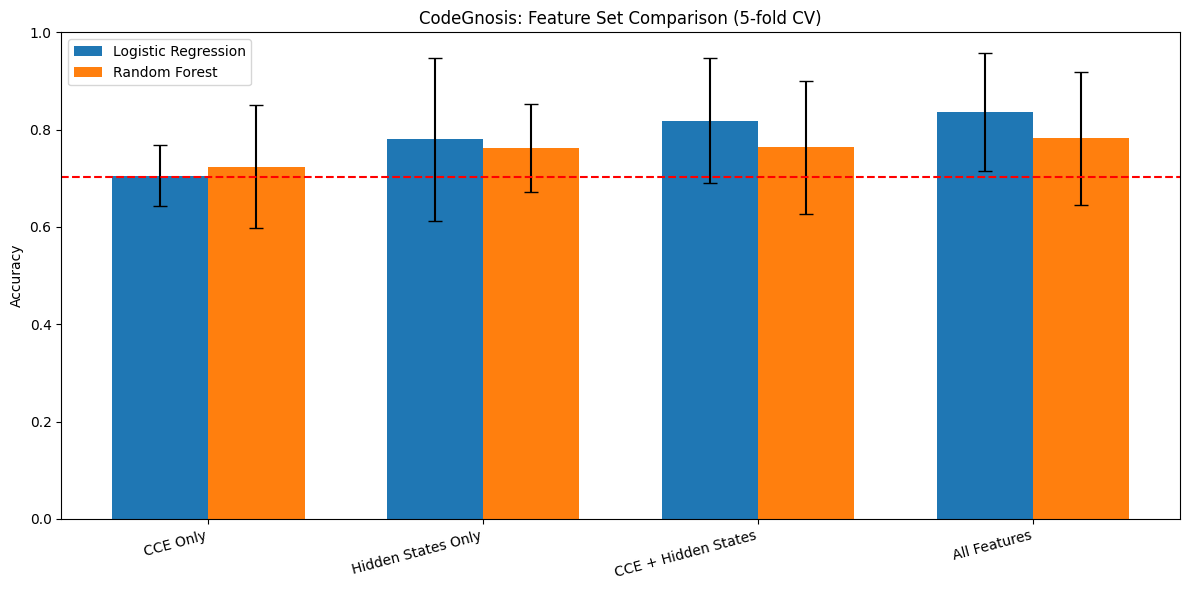


Majority class baseline: 0.704


In [12]:
# Visualize comparison
fig, ax = plt.subplots(figsize=(12, 6))

feature_set_names = list(results.keys())
x = np.arange(len(feature_set_names))
width = 0.35

lr_means = [results[fs]['Logistic Regression']['mean'] for fs in feature_set_names]
lr_stds = [results[fs]['Logistic Regression']['std'] for fs in feature_set_names]
rf_means = [results[fs]['Random Forest']['mean'] for fs in feature_set_names]
rf_stds = [results[fs]['Random Forest']['std'] for fs in feature_set_names]

ax.bar(x - width/2, lr_means, width, yerr=lr_stds, label='Logistic Regression', capsize=5)
ax.bar(x + width/2, rf_means, width, yerr=rf_stds, label='Random Forest', capsize=5)

ax.set_ylabel('Accuracy')
ax.set_title('CodeGnosis: Feature Set Comparison (5-fold CV)')
ax.set_xticks(x)
ax.set_xticklabels(feature_set_names, rotation=15, ha='right')
ax.legend()
ax.set_ylim(0, 1)

# Add baseline (majority class)
majority_baseline = max(y.mean(), 1 - y.mean())
ax.axhline(y=majority_baseline, color='red', linestyle='--', label=f'Majority baseline: {majority_baseline:.2f}')

plt.tight_layout()
plt.savefig('week14_v2_feature_comparison.png', dpi=150)
plt.show()

print(f"\nMajority class baseline: {majority_baseline:.3f}")

In [13]:
# Statistical significance test
print("="*70)
print("STATISTICAL SIGNIFICANCE: CCE Only vs All Features")
print("="*70)

cce_scores = results['CCE Only']['Logistic Regression']['scores']
all_scores = results['All Features']['Logistic Regression']['scores']

# Paired t-test
t_stat, p_value = stats.ttest_rel(all_scores, cce_scores)

print(f"\nCCE Only:      {cce_scores.mean():.3f} +/- {cce_scores.std():.3f}")
print(f"All Features:  {all_scores.mean():.3f} +/- {all_scores.std():.3f}")
print(f"\nPaired t-test: t={t_stat:.3f}, p={p_value:.4f}")

if p_value < 0.05:
    print("\n=> SIGNIFICANT: Hidden states + attention ADD value over CCE alone!")
else:
    print("\n=> NOT significant: No clear benefit from hidden states")

STATISTICAL SIGNIFICANCE: CCE Only vs All Features

CCE Only:      0.705 +/- 0.062
All Features:  0.836 +/- 0.121

Paired t-test: t=3.456, p=0.0259

=> SIGNIFICANT: Hidden states + attention ADD value over CCE alone!


FEATURE IMPORTANCE (Random Forest on All Features)

Top 10 most important features:
        feature  importance
    hs_max_norm    0.120174
     num_tokens    0.110131
       attn_max    0.097374
   cce_spikes_2    0.087216
        cce_max    0.080129
tokens_per_line    0.068309
        cce_q90    0.061202
        cce_std    0.060896
        cce_q75    0.049562
       attn_std    0.045014


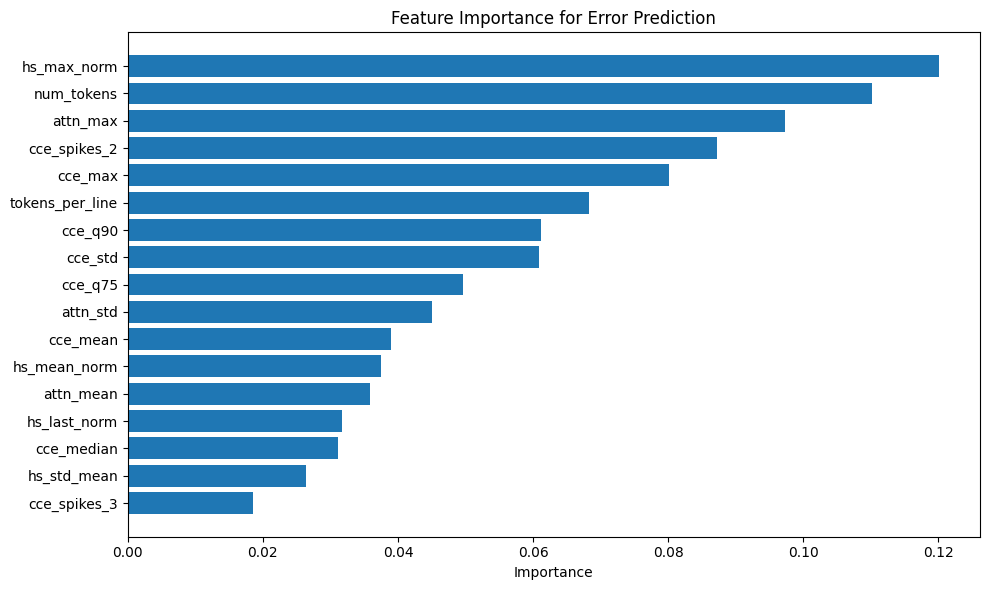

In [14]:
# Feature importance analysis
print("="*70)
print("FEATURE IMPORTANCE (Random Forest on All Features)")
print("="*70)

# Train on full data to get feature importances
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_scaled, y)

importances = pd.DataFrame({
    'feature': feature_names,
    'importance': rf.feature_importances_,
}).sort_values('importance', ascending=False)

print("\nTop 10 most important features:")
print(importances.head(10).to_string(index=False))

# Plot
plt.figure(figsize=(10, 6))
plt.barh(importances['feature'][::-1], importances['importance'][::-1])
plt.xlabel('Importance')
plt.title('Feature Importance for Error Prediction')
plt.tight_layout()
plt.savefig('week14_v2_feature_importance.png', dpi=150)
plt.show()

In [15]:
# Final summary
print("="*70)
print("FINAL SUMMARY")
print("="*70)

print(f"""
Dataset:
  Total samples: {len(training_data)}
  Correct: {sum(1 for g in training_data if g.is_correct)} ({100*sum(1 for g in training_data if g.is_correct)/len(training_data):.1f}%)
  Errors: {sum(1 for g in training_data if not g.is_correct)} ({100*sum(1 for g in training_data if not g.is_correct)/len(training_data):.1f}%)

Cross-Validation Results (Logistic Regression):
  CCE Only:           {results['CCE Only']['Logistic Regression']['mean']:.3f} +/- {results['CCE Only']['Logistic Regression']['std']:.3f}
  Hidden States Only: {results['Hidden States Only']['Logistic Regression']['mean']:.3f} +/- {results['Hidden States Only']['Logistic Regression']['std']:.3f}
  CCE + Hidden:       {results['CCE + Hidden States']['Logistic Regression']['mean']:.3f} +/- {results['CCE + Hidden States']['Logistic Regression']['std']:.3f}
  All Features:       {results['All Features']['Logistic Regression']['mean']:.3f} +/- {results['All Features']['Logistic Regression']['std']:.3f}
  Majority Baseline:  {majority_baseline:.3f}

Conclusion:
""")

best_cce = results['CCE Only']['Logistic Regression']['mean']
best_all = results['All Features']['Logistic Regression']['mean']

if best_all > best_cce + 0.05:
    print("  Hidden states + attention IMPROVE prediction over CCE alone.")
    print("  This validates the CodeGnosis approach for code error prediction.")
elif best_all > majority_baseline + 0.05:
    print("  Both CCE and hidden states help, but similar performance.")
    print("  Hidden states don't add much over CCE for this task.")
else:
    print("  Neither approach significantly beats majority baseline.")
    print("  Need more data or harder tasks to see differentiation.")

FINAL SUMMARY

Dataset:
  Total samples: 54
  Correct: 38 (70.4%)
  Errors: 16 (29.6%)

Cross-Validation Results (Logistic Regression):
  CCE Only:           0.705 +/- 0.062
  Hidden States Only: 0.780 +/- 0.167
  CCE + Hidden:       0.818 +/- 0.129
  All Features:       0.836 +/- 0.121
  Majority Baseline:  0.704

Conclusion:

  Hidden states + attention IMPROVE prediction over CCE alone.
  This validates the CodeGnosis approach for code error prediction.


In [16]:
# Save results
output = {
    'experiment': 'Week14_CodeGnosis_V2',
    'num_samples': len(training_data),
    'num_correct': sum(1 for g in training_data if g.is_correct),
    'num_errors': sum(1 for g in training_data if not g.is_correct),
    'majority_baseline': float(majority_baseline),
    'cv_results': {
        fs: {
            clf: {'mean': float(m['mean']), 'std': float(m['std'])}
            for clf, m in clf_results.items()
        }
        for fs, clf_results in results.items()
    },
    'feature_importance': importances.head(10).to_dict('records'),
}

with open('week14_v2_results.json', 'w') as f:
    json.dump(output, f, indent=2)

print("Results saved to week14_v2_results.json")

Results saved to week14_v2_results.json
